<h1>VQE for the Fermi-Hubbard Model</h1>

Simulating quantum systems is one of the main applications proposed for current and near-term quantum computers. Hybrid classical-quantum approaches, such as Variational Quantum Algorithms (VQAs), are promising candidates for this in the current Noisy Intermediate Scale Quantum, or NISQ, era. This hybrid approach involves running a quantum circuit on a quantum processing unit (QPU), while doing the optimisation of circuit parameters classically.

<h2>The Fermi-Hubbard Model</h2>
The Fermi-Hubbard Model is a lattice model that describes correlated electrons, and which is expected to be among the first models to demonstrate quantum advantage. It captures many interesting phenomena such as high-temperature superconductivity, quantum magnetism, and metal-insulator transitions [2].
The Fermi-Hubbard Hamiltonian is $$\hat{H} = -t\sum_{i, \sigma}\big{(}c_{i, \sigma}^{\dagger}c_{i+1, \sigma}+c_{i+1, \sigma}^{\dagger}
c_{i, \sigma}\big{)} + U{\sum_i}n_{i\uparrow}n_{i\downarrow},$$

where $U$ is an on-site repulsive Coulomb interaction between electrons and $t$ is kinetic energy or tunneling amplitude allowing the electrons to hop between neighboring lattice sites [2]. While being a relatively simple model of electron, solving this model for anything but small 1D systems is notoriously difficult for classical computers due to the exponential scaling of computational resources required to simulate it. 

<h2>Variational Quantum Eigensolver (VQE)</h2>

Variational Quantum Algorithms (VQAs) are a type of hybrid quantum-classical algorithm designed to work with the currently available noisy quantum computers. In a VQA, a parametrized quantum circuit is executed on a quantum computer and the circuit parameters are optimized classically with the goal of minimizing a cost function [1].

Variational Quantum Eigensolvers are a type of variational quantum algorithm designed for the purpose of finding the ground state of a quantum system or molecule. In a VQE, the cost function to be minimized in the classical optimization loop is the energy of the system given by the expectation value of the Hamiltonian, which once minimized gives the ground state energy of the system:

$$ E_0 = \text{min}_\theta⟨\psi(\theta)|H|\psi(\theta)⟩, $$

where $|\psi(\theta)⟩$ is the quantum state prepared by the parametrised circuit. By iteratively updating $\theta$
with a classical optimizer, the algorithm converges toward the ground state energy [1]. 

In this notebook, we implement VQE for the half-filled Fermi-Hubbard model.

<h3> Importing libraries </h3>

In [ ]:
# For visualization and other useful tools
import matplotlib.pyplot as plt
%matplotlib inline
from qiskit.visualization import plot_histogram
import numpy as np
import itertools
import time
import math
from qiskit.result import Counts
from itertools import combinations, product
from typing import List

# For the quantum part
from qiskit import QuantumCircuit
from qiskit.quantum_info import SparsePauliOp
from qiskit.circuit import ParameterVector
from qiskit.circuit.library import EfficientSU2, ExcitationPreserving
from qiskit.compiler import transpile
from iqm.qiskit_iqm.iqm_transpilation import optimize_single_qubit_gates, IQMOptimizeSingleQubitGates
from qiskit.quantum_info import SparsePauliOp, pauli_basis, Operator
from qiskit.primitives import StatevectorEstimator
from qiskit_ibm_runtime import Estimator, Session
import openfermion as of
from openfermion import QubitOperator
from openfermion.linalg import get_sparse_operator

# For classical optimization
""" importing optimization part from a separate file: learning_algorithm.py
    (or learning_algorithm_REM.py for readout error mitigation but initial layout needs to be selected in that file)"""
import sys
import os

sys.path.append(os.path.abspath("../LearningAlgorithm"))

from LearningAlgorithm.learning_algorithm import Learning

# For backend
from iqm import qiskit_iqm
from iqm.qiskit_iqm.fake_backends import fake_aphrodite
from iqm.qiskit_iqm import IQMProvider
from qiskit_aer import AerSimulator

<h3> Setting backend </h3>

In [ ]:
# UNCOMMENT YOUR CHOICE OF BACKEND
 
backend = AerSimulator()                      # fake backend without noise
#backend = fake_aphrodite.IQMFakeAphrodite()  # fake Q50
target = backend.target

# Helmi (VTT Q5) 5-qubit quantum computer (requires access)
HELMI_CORTEX_URL = os.getenv('HELMI_CORTEX_URL')
# provider = IQMProvider(HELMI_CORTEX_URL)
# backend = provider.get_backend()

# Q50 (VTT Q50) 52-qubit quantum computer (requires access)
Q50_CORTEX_URL = os.getenv('Q50_CORTEX_URL')
# provider_q50 = IQMProvider(Q50_CORTEX_URL)
# backend = provider_q50.get_backend()

<h3> Setting model parameters </h3>

In [ ]:
# Fermi-Hubbard model parameters                  
N_x = 1                 # number of spatial sites in the x-direction
N_y = 3                 # number of spatial sites in the y-direction
N = N_x * N_y
U = 50                  # repulsive on-site Coulomb interaction
t = 1.0                 # kinetic energy

<h3> Defining Hamiltonian for the Fermi-Hubbard Model </h3>

In [ ]:
# Fermi-Hubbard Hamiltonian from OpenFermion
hubbard_hamiltonian = of.fermi_hubbard(N_x, N_y, tunneling=t, coulomb=U, chemical_potential=U/2, periodic=False)

# Jordan-Wigner transformation
pauli_hubbard_hamiltonian = of.transforms.jordan_wigner(hubbard_hamiltonian)

# Converting Hamiltonian from openfermion to Qiskit SparsePauliOp
def openfermion_to_sparsepauliop(N, qubit_op):
    labels = []
    coeffs = []

    for term, coeff in qubit_op.terms.items():
        label = ['I'] * 2*N
        for qubit, pauli in term:
            label[qubit] = pauli
        labels.append(''.join(reversed(label)))
        coeffs.append(complex(coeff))

    return SparsePauliOp(labels, coeffs=np.array(coeffs))

# Permutation of Hamiltonian terms to get spin-blocked order 
def permute_sparsepauliop(N: int, op: SparsePauliOp) -> SparsePauliOp:
    """permutes Pauli terms to match qubit order,
    (for ex. N = 2 sites: interleaved |up0down0up1down1> to spin-blocked |up0up1down0down1>,
    where 0 and 1 are lattice sites and up and down are spin directions)"""

    def interleaved_to_spinblocked_permutation(N: int) -> list[int]:
        perm = [0]*(2*N)
        for site in range(N):
            perm[2*site + 0] = site      
            perm[2*site + 1] = site + N 
        return perm

    perm = interleaved_to_spinblocked_permutation(N)

    n = op.num_qubits

    new_labels = []
    for s in op.paulis.to_labels():  
        s_list = list(s)
        new = ['I'] * n
        for old in range(n):
            ch = s_list[-1 - old]
            if ch != 'I':
                new_index = perm[old]
                new[-1 - new_index] = ch
        new_labels.append(''.join(new))

    return SparsePauliOp(new_labels, coeffs=op.coeffs.copy()).simplify()

# Converting Hubbard Hamiltonian from Openfermion to Qiskit SparsePauliOp 
hamiltonian_sparsepauliop = openfermion_to_sparsepauliop(N, pauli_hubbard_hamiltonian)

# Permuting Hamiltonian terms to get spin-blocked order
hamiltonian_final = permute_sparsepauliop(N, hamiltonian_sparsepauliop)
print("Final Hamiltonian:", hamiltonian_final)
print("Pauli list:", hamiltonian_final.paulis)

Final Hamiltonian: SparsePauliOp(['IIZIYY', 'IIZIXX', 'IYYIZI', 'IXXIZI', 'IIZIIZ', 'IZIYYI', 'IZIXXI', 'YYIZII', 'XXIZII', 'IZIIZI', 'IIIIII', 'ZIIZII'],
              coeffs=[ -0.5+0.j,  -0.5+0.j,  -0.5+0.j,  -0.5+0.j,  12.5+0.j,  -0.5+0.j,
  -0.5+0.j,  -0.5+0.j,  -0.5+0.j,  12.5+0.j, -37.5+0.j,  12.5+0.j])
Pauli list: ['IIZIYY', 'IIZIXX', 'IYYIZI', 'IXXIZI', 'IIZIIZ', 'IZIYYI', 'IZIXXI',
 'YYIZII', 'XXIZII', 'IZIIZI', 'IIIIII', 'ZIIZII']


<h3> Parametrised quantum circuit </h3>

Creating a few parametrised circuit choices: hardware efficient (EfficientSU2), Hamiltonian Variational Ansatz (HVA), and a custom physically-inspired fermionic ansatz.

In [ ]:
# Efficient SU2 ansatz
ansatz_SU2 = EfficientSU2(2*N, reps=2, entanglement="circular")

# Half-filled initial state
def half_filled_initial_state(n_qubits, n_particles):
    qc = QuantumCircuit(n_qubits)
    for i in range(n_particles):
        qc.x(i)
    return qc

initial_state = half_filled_initial_state(2*N, N)

# Physically inspired fermionic ansatz
def givens_rotation(circuit, i, j, theta):
    # Applies a number-conserving Givens rotation between qubits i and j
    circuit.ry(-np.pi / 2, j)
    circuit.cx(i, j)
    circuit.ry(theta, j)
    circuit.cx(i, j)
    circuit.ry(np.pi / 2, j)

def fermionic(filling, N, layers):
    """
        filling: number of occupied modes for spin up/down as a list, for example [2, 2]
        N: number of spatial sites
        layers: number of ansatz layers
    """
    nqubits = 2 * N
    circuit = QuantumCircuit(nqubits)
    theta = ParameterVector('θ', 5 * layers * (nqubits - 1))
    k = 0

    # Initial state preparation based on filling
    for color, n_particles in enumerate(filling):
        count = 0
        for site in range(N):
            if count < n_particles:
                qubit = color * N + site
                circuit.x(qubit)
                count += 1

    # Variational layers of Givens Rotations
    for layer in range(layers):
        # Even layer Givens
        for i in range(0, nqubits - 1, 2):
            givens_rotation(circuit, i, i + 1, theta[k])
            k += 1
        # Odd layer Givens
        for i in range(1, nqubits - 1, 2):
            givens_rotation(circuit, i, i + 1, theta[k])
            k += 1
        for i in range(N):
            q_up = i         
            q_down = i + N
            givens_rotation(circuit, q_up, q_down, theta[k])
            k += 1

    return circuit

ansatz_fermionic = fermionic([1, 1], N, 2)

# Number preserving ansatz (Qiskit)
NP_ansatz = ExcitationPreserving(num_qubits=2*N, mode='fsim', entanglement='linear', reps=2, skip_unentangled_qubits=True, skip_final_rotation_layer=True, parameter_prefix='s', insert_barriers=False, name='ExcitationPreserving', flatten=True)

# Hamiltonian Variational Ansatz (custom HVA ansatz)
def givens_rotation(circuit, i, j, theta):
    """Applies a Givens rotation (number-conserving) between qubits i and j."""
    circuit.ry(-np.pi / 2, j)
    circuit.cx(i, j)
    circuit.ry(theta, j)
    circuit.cx(i, j)
    circuit.ry(np.pi / 2, j)

def hva_ansatz(N, layers):
    """
        N: number of spatial sites
        layers: number of HVA circuit layers
    """
    n_qubits = 2 * N  # spin-1/2 fermions: 2 modes per site
    circuit = QuantumCircuit(n_qubits)
    theta_t = ParameterVector('θ_t', layers * (n_qubits - 1))  # hopping terms
    theta_u = ParameterVector('θ_u', layers * N)               # interaction terms
    k_t = 0
    k_u = 0

    # Initial state: one up and one down electron
    circuit.x(0)       # ↓ at site 0 (qubit 0)
    circuit.x(N)       # ↑ at site 0 (qubit L)

    # HVA layers
    for l in range(layers):
        # Hopping terms: apply Givens rotations between neighbors
        for i in range(0, n_qubits - 1):
            givens_rotation(circuit, i, i + 1, theta_t[k_t])
            k_t += 1

        # On-site interaction terms: apply RZZ between up and down spin at same site
        for site in range(N):
            q_down = site
            q_up = site + N
            circuit.rzz(theta_u[k_u], q_down, q_up)
            k_u += 1

    return circuit

ansatz_HVA_custom = hva_ansatz(N, 3)


<h3> Classical optimization </h3>

For conciseness, the classical optimization loop has been imported from a separate file _learning_algorithm.py_. The classical optimizer can be selected here, but other changes to optimizer settings or adding new optimizer options can be done by editing _learning_algorithm.py_.

In [ ]:
# Setting ansatz choice
ansatz_choice = ansatz_fermionic.compose(NP_ansatz)
# ansatz_choice = initial_state.compose(anstazSU2)
# ansatz_choice = ansatz_HVA_custom

# Transpiling circuit
transpiled_circuit = transpile(ansatz_choice, target=backend.target, layout_method="trivial", routing_method="sabre", optimization_level=3)

# Removing unused qubits
def remove_unused_qubits(circuit: QuantumCircuit) -> QuantumCircuit:
    # Identify used qubits
    used_qubits = set()
    for instr, qargs, _ in circuit.data:
        for qubit in qargs:
            used_qubits.add(qubit)

    # Map old qubits to new indices
    qubit_map = {qubit: idx for idx, qubit in enumerate(sorted(used_qubits, key=lambda q: circuit.qubits.index(q)))}
    new_circ = QuantumCircuit(len(used_qubits))

    # Rebuild the circuit
    for instr, qargs, cargs in circuit.data:
        new_qargs = [new_circ.qubits[qubit_map[q]] for q in qargs]
        new_circ.append(instr, new_qargs, cargs)

    return new_circ

ansatz = remove_unused_qubits(transpiled_circuit)

# Matching Hamiltonian and circuit dimensions (required by estimator)
def pad_hamiltonian(ham: SparsePauliOp, total_qubits: int) -> SparsePauliOp:
    current_qubits = ham.num_qubits
    if current_qubits == total_qubits:
        return ham
    elif current_qubits > total_qubits:
        raise ValueError("Hamiltonian has more qubits than the circuit.")

    # Pad with identities on the left (least significant qubits)
    n_pad = total_qubits - current_qubits
    padding = SparsePauliOp.from_list([('I' * n_pad, 1.0)])
    padded_ham = ham.tensor(padding)
    return padded_ham

hamiltonian = pad_hamiltonian(hamiltonian_final, ansatz.num_qubits)

"""Choosing optimizer (options include: "cobyla", "SPSA", "basinhopping", "dual_annealing", "BFGS", and "gp_minimize")
SPSA is recommended for running on real QPU (most tolerant against noise and uses only 2 circuit runs per iteration)"""
optimizer = "cobyla"
# Setting estimator
#estimator = StatevectorEstimator()         # can be used with simulators only
session = Session(backend=backend)
estimator = Estimator(mode=session)         # can be used with simulators and with real QPUs
estimator.options.default_shots = 10000

# Running optimization loop
learning = Learning(ansatz, hamiltonian, backend, estimator, optimizer)
start = time.time()
result = learning.run()
session.close()
end = time.time()
runtime = end - start
print("Runtime:", runtime)
print(f"VQE runtime: {runtime:.2f} seconds")
print(f'Calculated cost: {learning.energy}')
print(f'Calculated parameters: {learning.params}')

H_matrix = Operator(hamiltonian).data
eigenvalues = np.linalg.eigvalsh(H_matrix)
print()
print("Min eigenvalue (exact ground state):", np.min(eigenvalues))
print("Energy error:", abs(np.min(eigenvalues))-abs(learning.energy))


Iterations: 1 | Current cost: -0.015599999999995617

Iterations: 2 | Current cost: 0.0015000000000000568

Iterations: 3 | Current cost: -0.037299999999998334

Iterations: 4 | Current cost: -0.0492000000000008

Iterations: 5 | Current cost: -0.023099999999999454

Iterations: 6 | Current cost: -0.003299999999997638

Iterations: 7 | Current cost: -0.008800000000000807

Iterations: 8 | Current cost: -35.8805

Iterations: 9 | Current cost: -35.7171

Iterations: 10 | Current cost: -36.0693

Iterations: 11 | Current cost: -35.9812

Iterations: 12 | Current cost: -45.892799999999994

Iterations: 13 | Current cost: -46.028600000000004

Iterations: 14 | Current cost: -46.3291

Iterations: 15 | Current cost: -46.5308

Iterations: 16 | Current cost: -35.3656

Iterations: 17 | Current cost: -46.412000000000006

Iterations: 18 | Current cost: -45.8199

Iterations: 19 | Current cost: -46.6887

Iterations: 20 | Current cost: -46.7282

Iterations: 21 | Current cost: -46.4005

Iterations: 22 | Current 

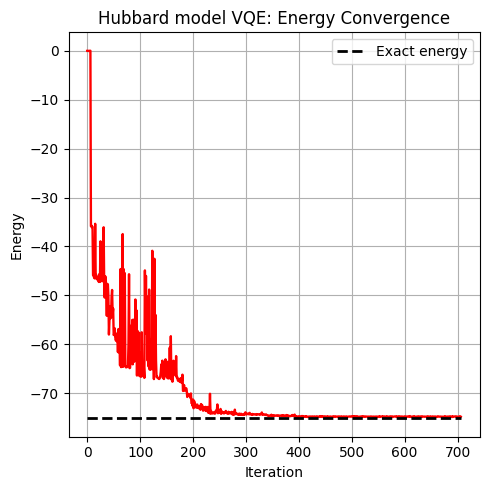

In [ ]:
energies1 = learning.costs_dictionary["costs"]
num_iters = len(learning.costs_dictionary["costs"])

# --------- Plotting energy convergence ----------- #

f1 = plt.figure(figsize=(5,5))
ax1 = f1.add_subplot(1, 1, 1)
plt.plot(energies1, color = 'red', linewidth=1.7)
plt.hlines(np.min(eigenvalues), xmin=0, xmax=num_iters, label='Exact energy', color='black', linestyles='dashed', linewidth=2.0)
plt.xlabel("Iteration")
plt.ylabel("Energy")
plt.title("Hubbard model VQE: Energy Convergence")
plt.grid(True)
plt.tight_layout()
plt.legend()
plt.show()

In [ ]:
# Defining count filtering function
def filter_counts_by_particle_number(counts: Counts, target_particles: int) -> Counts:
    """Keep only bitstrings with a Hamming weight corresponding to particle number."""
    filtered_counts = {
        bitstr: count for bitstr, count in counts.items()
        if bitstr.count('1') == target_particles
    }
    total = sum(filtered_counts.values())
    if total == 0:
        raise ValueError("No bitstrings matched the target particle number.")
    # Renormalize
    original_total = sum(filtered_counts.values())
    probabilities = {bitstr: count/original_total for bitstr, count in filtered_counts.items()}
    
    scaled_counts = {}
    remainders = []
    
    for bitstr, prob in probabilities.items():
        exact = prob * 10000
        integer = int(exact)
        scaled_counts[bitstr] = integer
        remainders.append((bitstr, exact - integer))
    
    remaining = 10000 - sum(scaled_counts.values())
    for bitstr, remainder in sorted(remainders, key=lambda x: -x[1])[:remaining]:
        scaled_counts[bitstr] += 1
    
    return scaled_counts

# Compiling to backend and binding parameters
values = learning.params
bound_circuit = ansatz.assign_parameters(values)
bound_circuit.measure_all()
transpiled_job = transpile(bound_circuit, target=backend.target, layout_method="trivial", routing_method="sabre", optimization_level=3)

# Getting counts
job = backend.run(transpiled_job, shots=10000)
print("Qiskit counts:", job.result().get_counts())
filtered = filter_counts_by_particle_number(job.result().get_counts(), target_particles = N)
print("Post-selected counts:", filtered)
noiseless_job = AerSimulator().run(transpiled_job, shots=10000)
print("Noiseless counts:", noiseless_job.result().get_counts())

Qiskit counts: {'010111': 1, '010011': 1, '001101': 8, '010001': 6, '010100': 12, '111101': 2, '100101': 1, '011001': 21, '000101': 33, '000111': 3, '010101': 9912}
Post-selected counts: {'010011': 1, '001101': 8, '100101': 1, '011001': 21, '000111': 3, '010101': 9966}
Noiseless counts: {'010110': 1, '011101': 3, '010011': 2, '000101': 27, '111101': 1, '011001': 31, '010101': 9909, '000111': 4, '001101': 6, '010100': 6, '010001': 10}


<h2> References </h2>

[1] M. Cerezo, A. Arrasmith, R. Babbush, et al. “Variational quantum algorithms”, Nat Rev Phys 3, pp. 625–644 (2021). doi: https://doi.org/10.1038/s42254-021-00348-9

[2] D. Wecker, M. Hastings, N. Wiebe. “Solving strongly correlated electron models on a quantum computer”, Phys. Rev. A 92, 062318 (2015). doi: https://doi.org/10.1103/PhysRevA.92.062318